# Every Fit Method — MAP, Laplace, ADVI, Pathfinder, SMC & NUTS

`BayesianMMM.fit(method=...)` can estimate the same model **seven** ways. Two are
*exact* samplers: full **NUTS** MCMC (the reference, and the workhorse for final
inference) and tempered **SMC** (Sequential Monte Carlo — slower per effective
draw, but immune to mode-locking and the only method that estimates the **log
marginal likelihood** for model comparison). One is a bare *point estimate*
(**MAP**). The remaining four are *approximate* posteriors that fit in seconds
and are meant for **model checking** (bad priors, broken geometry, pathological
saturation/adstock) *before* you pay for a full sample — their uncertainty is
**not calibrated**, and this notebook shows *exactly how* their posteriors
differ in shape.

The methods differ in the family of posterior *shapes* they can represent:

| Method | Kind | Approximating family | Correlations? | Non-Gaussian shape? |
|---|---|---|---|---|
| **NUTS** (`nuts`) | exact | *the posterior itself* (samples) | **Yes** | **Yes** — skew, funnels, heavy tails |
| **SMC** (`smc`) | exact | weighted particles tempered prior → posterior | **Yes** | **Yes** — including *multiple modes* |
| **MAP** (`map`) | point | a single mode location | — | — |
| **Laplace** (`laplace`) | approximate | one Gaussian from the *curvature at the MAP mode* | **Yes** (linear) | No — elliptical |
| **Full-rank ADVI** (`fullrank_advi`) | approximate | one *full-covariance* Gaussian (unconstrained) | **Yes** (linear) | No — elliptical |
| **Pathfinder** (`pathfinder`) | approximate | Gaussians along a quasi-Newton path + importance resampling | **Yes** (linear) | Weakly (via resampling) |
| **Mean-field ADVI** (`advi`) | approximate | independent Gaussians in the *unconstrained* space | **No** — forced to zero | Only what the constraint transform induces |

> The failure modes to watch for: **(1)** mean-field ADVI cannot see
> correlations between parameters, so it collapses posterior *ridges* to
> axis-aligned blobs and reports **over-confident** (too narrow) marginals;
> **(2)** every Gaussian-family approximation is single-mode and (in the
> unconstrained space) symmetric, so genuine skew / curvature is lost; and
> **(3)** even the exact methods have their own diagnostics to read — R-hat /
> ESS / divergences for NUTS, R-hat *across independent runs* for SMC. We fit
> all seven and look.

In [1]:
import sys, pathlib, warnings, logging, os, contextlib, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, pearsonr

warnings.filterwarnings("ignore")
for _n in ("pymc", "pymc.sampling", "numpyro", "jax", "arviz", "pytensor"):
    _lg = logging.getLogger(_n); _lg.setLevel(logging.ERROR); _lg.propagate = False
sys.path.insert(0, str(pathlib.Path.cwd().parents[1]))  # repo root (kernel cwd is demos/)


@contextlib.contextmanager
def quiet():
    "Hide the samplers' progress bars / chatter; our own prints stay visible."
    with open(os.devnull, "w") as _dn, contextlib.redirect_stdout(_dn), \
            contextlib.redirect_stderr(_dn):
        yield


plt.rcParams.update({
    "figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 120,
})
INK, SKY, LEAF, BERRY, MUTED = "#2b2118", "#3b6ea5", "#3f7d5e", "#a63a50", "#8a8079"
GOLD, PLUM = "#b8860b", "#7d5ba6"

# Method registry: (label, fit-arg, colour) for every method that produces
# posterior DRAWS. NUTS is the reference throughout; SMC is the second exact
# sampler. MAP is a single point (no draws) and is handled separately.
METHODS = [
    ("NUTS",            "nuts",          INK),
    ("SMC",             "smc",           GOLD),
    ("Laplace",         "laplace",       PLUM),
    ("Full-rank ADVI",  "fullrank_advi", SKY),
    ("Pathfinder",      "pathfinder",    LEAF),
    ("Mean-field ADVI", "advi",          BERRY),
]
COLOR = {label: c for label, _, c in METHODS}
COLOR["MAP"] = MUTED
print("scipy + matplotlib ready; six draw methods + MAP registered.")

scipy + matplotlib ready; six draw methods + MAP registered.


---
## 1 — One dataset, one model

To isolate *inference* from *misspecification* we use a **positive control**:
`make_clean` draws data from the model's exact generative family (geometric
adstock, `1-exp(-λx)` saturation, additive, Gaussian noise, constant betas,
exogenous spend). So any difference between the methods below is the
approximation, **not** the model being wrong. Four media channels, one control
(price), three years of weekly data.

In [2]:
from mmm_framework.synth import dgp
from mmm_framework.config import InferenceMethod, ModelConfig
from mmm_framework.model import BayesianMMM, TrendConfig, TrendType

sc = dgp.make_clean(seed=0)
print(f"channels : {sc.channels}")
print(f"weeks    : {len(sc.y)}   controls: {list(sc.controls.columns)}")
print(f"true incremental contribution (KPI units):")
print(sc.true_contribution.round(0).to_string())

# ONE model object; we refit it seven ways. Parametric adstock so each channel
# exposes beta / adstock_alpha / sat_lam as free parameters we can inspect.
cfg = ModelConfig(
    inference_method=InferenceMethod.BAYESIAN_NUMPYRO,
    n_chains=4, n_draws=500, n_tune=1000,          # NUTS -> 2000 reference draws
    use_parametric_adstock=True, optim_seed=0,
)
model = BayesianMMM(sc.panel(), cfg, TrendConfig(type=TrendType.LINEAR))
N_APPROX = 2000  # draws taken from each fitted approximation (match NUTS total)

channels : ['TV', 'Search', 'Social', 'Display']
weeks    : 156   controls: ['Price']
true incremental contribution (KPI units):
TV         5668.0
Search     4531.0
Social     4017.0
Display    2958.0


## 2 — Fit all seven ways

Same model, same seed, same data. For each draw-producing method we keep the
posterior draws and the wall-clock time, and — because the world is synthetic —
we grade the downstream decision (per-channel incremental contribution) against
the **known** truth right after each fit, while the model still holds that
method's trace. Notes on the two special cases: for **SMC**, `draws` means
*particles per run* and `chains` means *independent tempered runs* (R-hat is
computed **across** them — that is SMC's multimodality check), and the result is
**not** flagged approximate; **MAP** returns a single point, so it is fitted at
the end and graded as a point estimate only.

In [3]:
traces, timings, contribs = {}, {}, {}

for label, arg, _ in METHODS:
    t = time.perf_counter()
    with quiet():
        if arg == "nuts":
            res = model.fit(random_seed=0)                     # full MCMC
        elif arg == "smc":
            # exact SMC: 4 independent runs x 2000 particles. The particle count
            # is SMC's quality knob — at 500 particles this model's runs
            # DISAGREE (R-hat 1.4, 14-nat evidence spread; see §8.5); 2000
            # brings them into agreement.
            res = model.fit(method="smc", draws=2000, chains=4, random_seed=0)
        elif arg == "laplace":
            # A Laplace fit is only as good as the optimum it is expanded at.
            # The default quasi-Newton (BFGS) optimizer is run-to-run fragile
            # on this model's ridges — it can stop where curvature is not yet
            # real and report wildly inflated SDs (we measured a 76x median SD
            # blow-up on one run). An exact-Hessian trust-region reliably
            # reaches the mode; see §8.4.
            res = model.fit(method=arg, draws=N_APPROX, random_seed=0,
                            optimize_method="trust-ncg", use_hess=True)
        else:
            res = model.fit(method=arg, draws=N_APPROX, random_seed=0)
    timings[label] = time.perf_counter() - t
    traces[label] = res.trace.posterior
    if arg == "nuts":
        nuts_res = res            # keep the full InferenceData for §8 diagnostics
    if arg == "smc":
        smc_res = res             # kept for §8: evidence + R-hat across runs

    # Decision quantity: incremental contribution per channel with a 90% band.
    with quiet():
        cc = model.compute_counterfactual_contributions(
            compute_uncertainty=True, hdi_prob=0.9, random_seed=0)
    contribs[label] = cc

    ndraws = int(np.prod([traces[label].sizes[d] for d in ("chain", "draw")]))
    extra = ""
    if arg in ("nuts", "smc"):
        extra = f"   r-hat={res.diagnostics['rhat_max']:.3f}"
        if arg == "nuts":
            extra += f"  div={res.diagnostics['divergences']}"
        else:
            lml = res.diagnostics.get("log_marginal_likelihood")
            if lml is not None:
                extra += f"  log-evidence={lml:.0f}"
    print(f"{label:16s}  {timings[label]:6.1f}s   {ndraws:5d} draws"
          f"   approximate={res.approximate}{extra}")

# MAP last: a single optimizer point, not a posterior. Graded in §3 (mode
# location), §7 (decision point) and §8.1 (speed); it has no spread to compare.
t = time.perf_counter()
with quiet():
    map_res = model.fit(method="map", random_seed=0)
timings["MAP"] = time.perf_counter() - t
with quiet():
    map_cc = model.compute_counterfactual_contributions(
        compute_uncertainty=False, random_seed=0)
print(f"{'MAP':16s}  {timings['MAP']:6.1f}s   {1:5d} draw "
      f"   approximate={map_res.approximate}   (point estimate)")

# Scalar (0-dim) parameters shared by every trace, in a readable order.
ref = traces["NUTS"]
SCALARS = [v for v in ref.data_vars if ref[v].ndim == 2]           # (chain, draw)
MEDIA = [p for p in SCALARS if any(p.endswith(c) for c in sc.channels)]
print("\nscalar parameters:", SCALARS)


def flat(post, var):
    "All draws of a scalar var as a 1-D array (chains pooled)."
    return np.asarray(post[var]).reshape(-1)


MAP_POINT = {p: float(flat(map_res.trace.posterior, p)[0]) for p in SCALARS}

  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]

Output()

...

Output()

Output()

Output()

Output()

MAP                  2.3s       1 draw    approximate=True   (point estimate)

scalar parameters: ['intercept', 'trend_slope', 'adstock_alpha_TV', 'sat_lam_TV', 'beta_TV', 'adstock_alpha_Search', 'sat_lam_Search', 'beta_Search', 'adstock_alpha_Social', 'sat_lam_Social', 'beta_Social', 'adstock_alpha_Display', 'sat_lam_Display', 'beta_Display', 'sigma']


> Speed vs fidelity in one glance: MAP and the approximate methods finish in
> seconds; the two exact samplers (NUTS, SMC) take real time. Note the
> `approximate=` column — SMC reports `False` because it *is* the posterior, and
> it is the only row with a `log-evidence` number. The question for the rest of
> the notebook is **what did the fast methods get wrong about the posterior?**

---
## 3 — Marginal shapes (one channel in detail)

Start with the *marginals* — the posterior of one parameter at a time. Below,
every panel overlays the four methods for TV's parameters. NUTS (filled grey) is
the reference. Two things to look for: does the approximate **spread** match, and
does the approximate **shape** match (positive parameters have skewed, not
Gaussian, posteriors)?

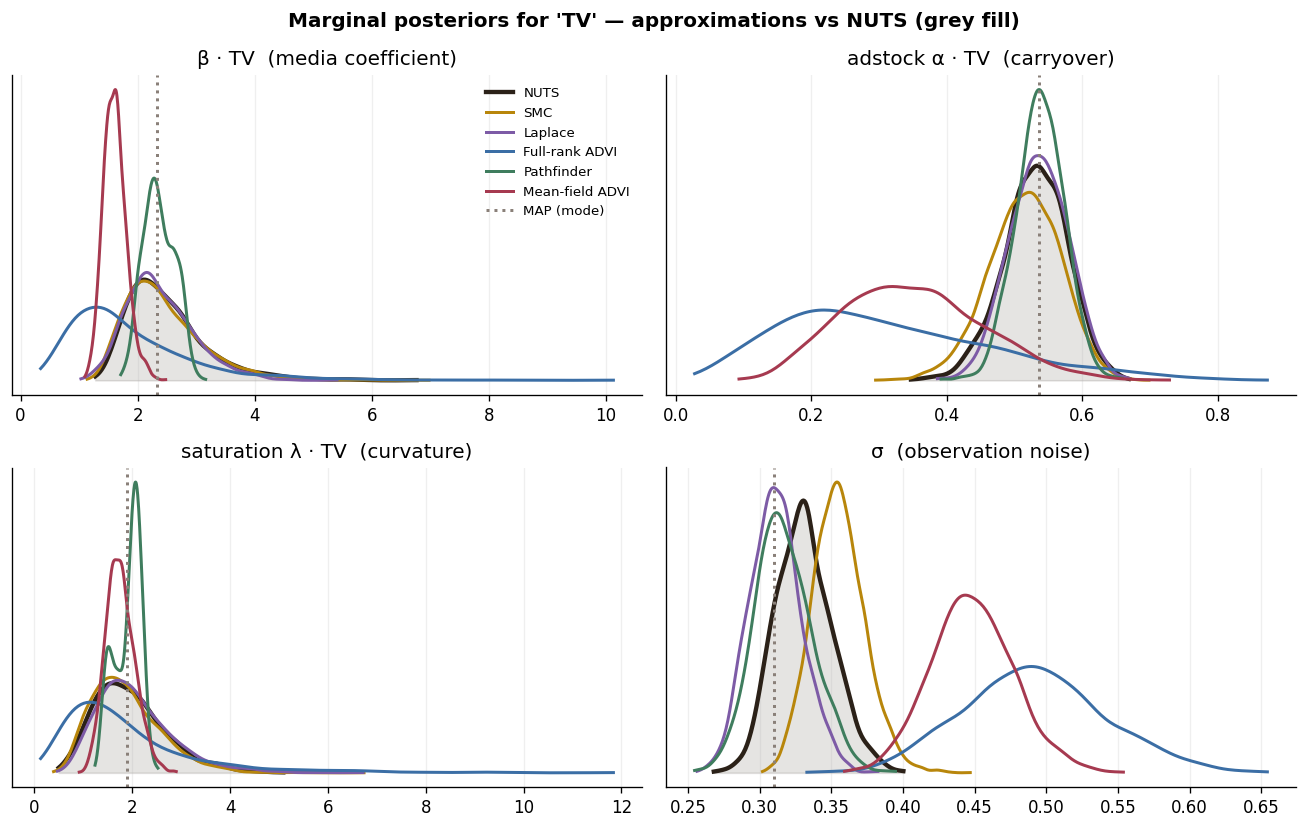

In [4]:
def kde_line(ax, x, color, label, lw=2.0):
    x = x[np.isfinite(x)]
    grid = np.linspace(x.min(), x.max(), 200)
    ax.plot(grid, gaussian_kde(x)(grid), color=color, lw=lw, label=label)


focus = "TV"
params = [f"beta_{focus}", f"adstock_alpha_{focus}", f"sat_lam_{focus}"]
params = [p for p in params if p in SCALARS] + ["sigma"]
titles = {f"beta_{focus}": f"β · {focus}  (media coefficient)",
          f"adstock_alpha_{focus}": f"adstock α · {focus}  (carryover)",
          f"sat_lam_{focus}": f"saturation λ · {focus}  (curvature)",
          "sigma": "σ  (observation noise)"}

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, p in zip(axes.ravel(), params):
    nuts = flat(traces["NUTS"], p)
    g = np.linspace(nuts.min(), nuts.max(), 200)
    ax.fill_between(g, gaussian_kde(nuts)(g), color=INK, alpha=0.12, zorder=0)
    for label, _, _ in METHODS:
        kde_line(ax, flat(traces[label], p), COLOR[label], label,
                 lw=2.6 if label == "NUTS" else 1.8)
    ax.axvline(MAP_POINT[p], color=MUTED, ls=":", lw=1.8, label="MAP (mode)")
    ax.set(title=titles.get(p, p), yticks=[]); ax.grid(alpha=0.2)
axes[0, 0].legend(fontsize=8, frameon=False)
fig.suptitle(f"Marginal posteriors for '{focus}' — approximations vs NUTS (grey fill)",
             fontweight="bold")
fig.tight_layout(); plt.show()

**What to notice.** The approximate marginals sit roughly in the right *place*
(the posterior mean is usually fine) but the **width and shape** drift.
Mean-field ADVI marginals are typically the narrowest — it spends no probability
mass on the correlated directions it cannot see, so it looks more certain than it
should. Positive parameters (`β`, `λ`) have right-skewed posteriors under NUTS;
the Gaussian-in-unconstrained-space methods recover *some* skew through the
log/logit transform but not the true tail. **SMC** (gold) should track the NUTS
fill closely — it is the one other method drawing from the true posterior — with
any roughness coming from its finite particle count, not a wrong family.
**Laplace** (plum) is the curvature Gaussian at the dotted **MAP** mode: right
place, symmetric shape. Note the MAP line sits at the *mode*, which for a skewed
posterior is systematically to one side of the mean — a first hint that a point
estimate is not a summary of the distribution.

## 4 — Is the spread right? (calibration across all parameters)

The marginals above were one channel. Here is the posterior **standard deviation
of every scalar parameter**, as a ratio `SD(approx) / SD(NUTS)`. A well-calibrated
approximation sits on the dashed line at **1.0**. Below the line = **over-confident**
(too narrow); above = under-confident.

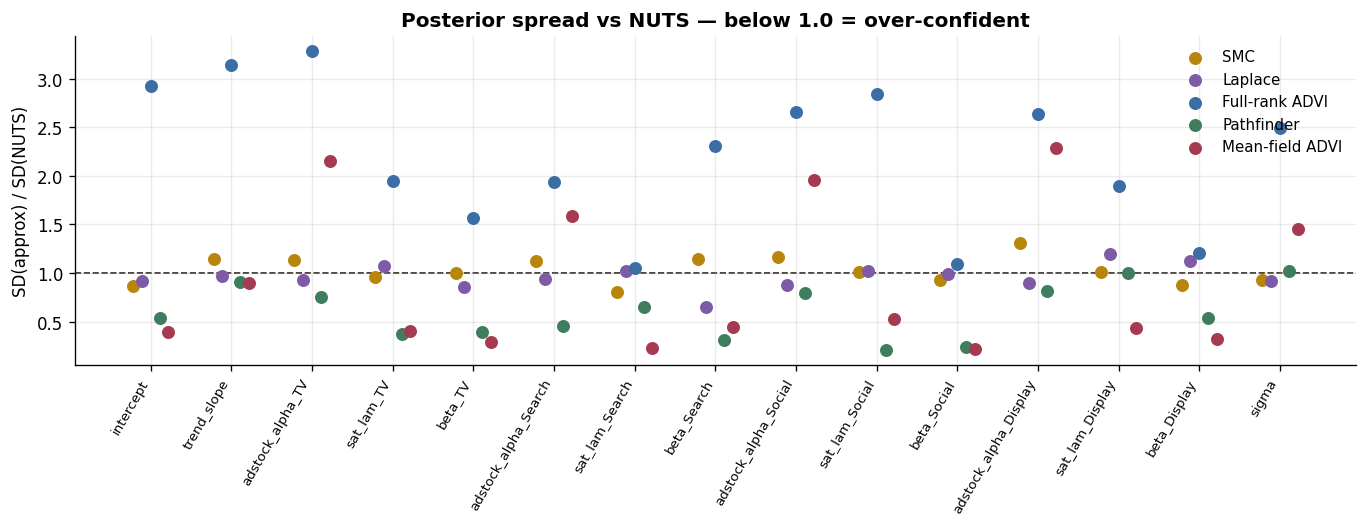

median SD ratio vs NUTS (1.0 = calibrated):
SMC                1.01
Laplace            0.94
Full-rank ADVI     2.30
Pathfinder         0.54
Mean-field ADVI    0.45


In [5]:
sd = {label: {p: flat(traces[label], p).std() for p in SCALARS} for label, _, _ in METHODS}
ratio = pd.DataFrame({label: {p: sd[label][p] / sd["NUTS"][p] for p in SCALARS}
                      for label, _, _ in METHODS if label != "NUTS"})

fig, ax = plt.subplots(figsize=(11.5, 4.5))
x = np.arange(len(SCALARS))
others = [m[0] for m in METHODS if m[0] != "NUTS"]
for i, label in enumerate(others):
    ax.scatter(x + (i - (len(others) - 1) / 2) * 0.11, ratio[label].values, s=46,
               color=COLOR[label], label=label, zorder=3)
ax.axhline(1.0, color=INK, ls="--", lw=1, zorder=1)
ax.set_xticks(x); ax.set_xticklabels(SCALARS, rotation=60, ha="right", fontsize=8)
ax.set_ylabel("SD(approx) / SD(NUTS)")
ax.set_title("Posterior spread vs NUTS — below 1.0 = over-confident", fontweight="bold")
ax.legend(frameon=False, fontsize=9); fig.tight_layout(); plt.show()

print("median SD ratio vs NUTS (1.0 = calibrated):")
print(ratio.median().round(2).to_string())

Read the printed medians alongside the plot. **SMC is the control here**: as the
other exact sampler its ratio should hover near 1.0, and any wobble is finite
particles, not a wrong family — if SMC sat far from 1.0 you would suspect the
run, not the posterior. For the approximations the lesson is **not** a clean
ranking — it is that the spread is uncalibrated in a direction you cannot
predict ahead of time. In this run **mean-field ADVI** and **Pathfinder** sit
*below* 1.0 (over-confident, too narrow), while **full-rank ADVI** sits well
*above* 1.0 (bands wider than NUTS); **Laplace** depends on how Gaussian the
posterior really is at the mode — fine where the quadratic expansion holds,
wrong where the tail is skewed. Mean-field is the one method that is *reliably*
over-confident: the variance it drops along the correlated directions (see §5) is
variance it never puts back. Either way the conclusion is the same — do not report
an approximate interval to a decision-maker.

---
## 5 — The correlation a mean-field fit cannot see

MMM posteriors have strong **ridges**: you can raise a channel's coefficient `β`
and steepen its saturation `λ` (or lengthen its adstock `α`) and fit the data
almost as well — the parameters *trade off*. That trade-off is a correlation in
the posterior, and it is exactly what mean-field ADVI throws away.

We pick the most strongly-correlated pair of media parameters **under NUTS**, then
draw the joint posterior for each method.

most-correlated media pair under NUTS: sat_lam_Social vs beta_Social   (r = -0.85)


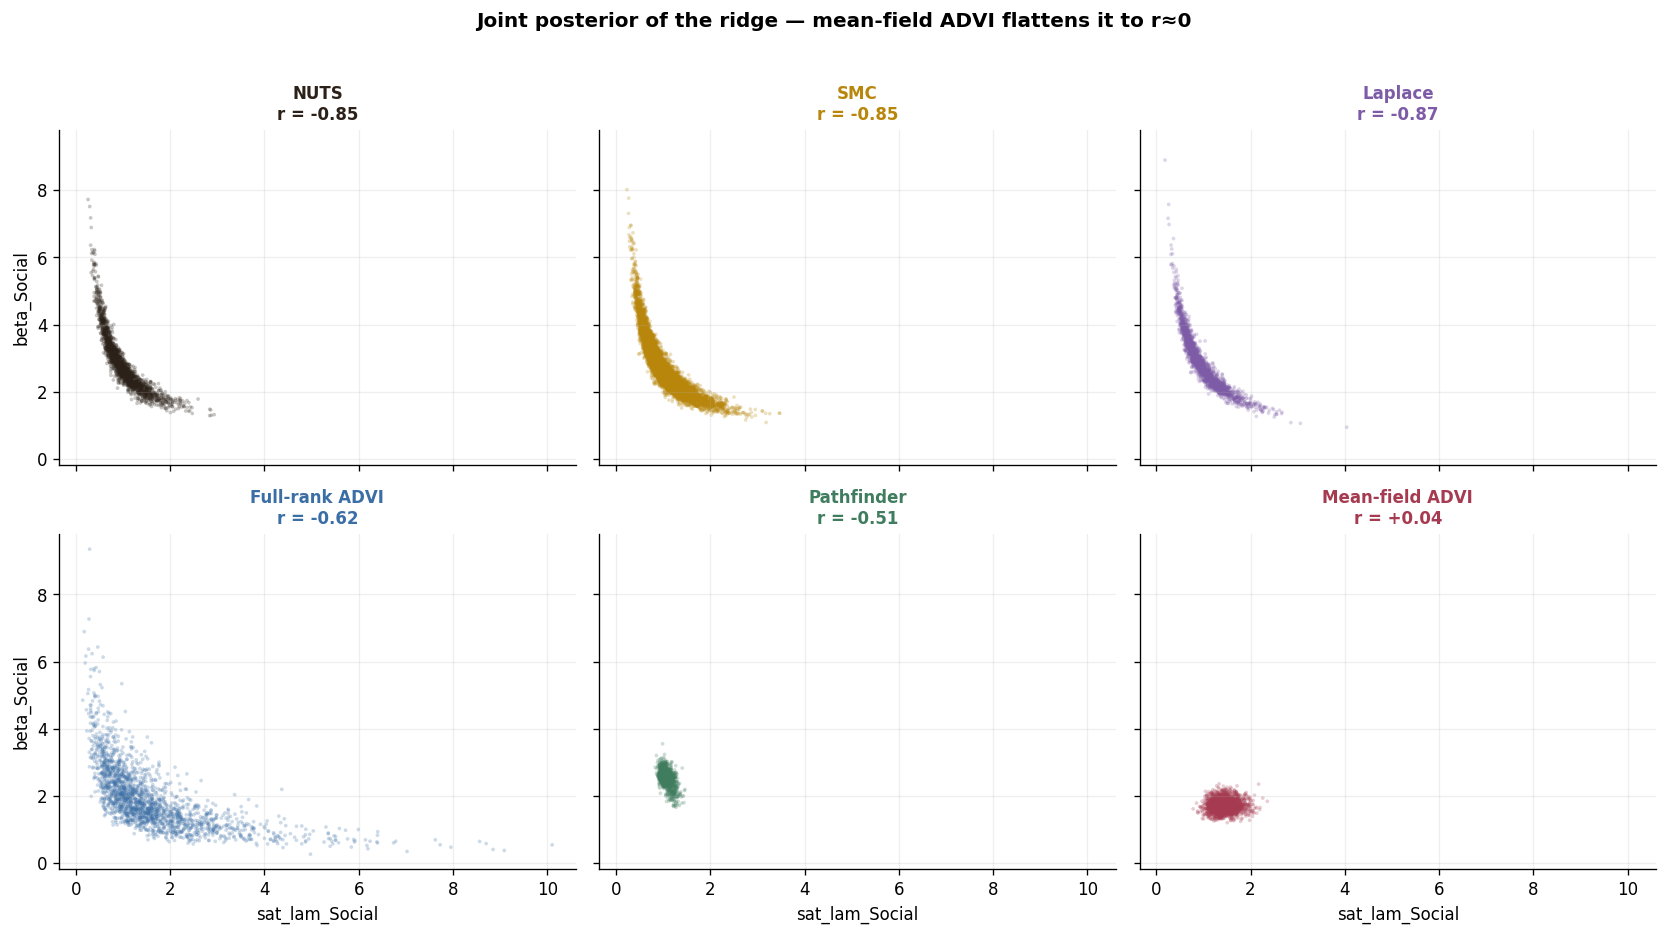

In [6]:
# Find the media-parameter pair with the largest |correlation| under NUTS.
best, best_r = None, 0.0
for i in range(len(MEDIA)):
    for j in range(i + 1, len(MEDIA)):
        a, b = MEDIA[i], MEDIA[j]
        r = np.corrcoef(flat(traces["NUTS"], a), flat(traces["NUTS"], b))[0, 1]
        if abs(r) > abs(best_r):
            best, best_r = (a, b), r
pa, pb = best
print(f"most-correlated media pair under NUTS: {pa} vs {pb}   (r = {best_r:+.2f})")

fig, axes = plt.subplots(2, 3, figsize=(14, 7.6), sharex=True, sharey=True)
for ax, (label, _, _) in zip(axes.ravel(), METHODS):
    xa, xb = flat(traces[label], pa), flat(traces[label], pb)
    r = pearsonr(xa, xb)[0]
    ax.scatter(xa, xb, s=5, alpha=0.25, color=COLOR[label], edgecolors="none")
    ax.set_title(f"{label}\nr = {r:+.2f}", fontsize=10,
                 color=COLOR[label], fontweight="bold")
    ax.grid(alpha=0.2)
for ax in axes[1]:
    ax.set_xlabel(pa)
for ax in axes[:, 0]:
    ax.set_ylabel(pb)
fig.suptitle("Joint posterior of the ridge — mean-field ADVI flattens it to r≈0",
             fontweight="bold", y=1.02)
fig.tight_layout(); plt.show()

**The headline.** NUTS shows a tilted (often curved) cloud — the real trade-off —
and **SMC**, the other exact sampler, reproduces the same tilt from a completely
different algorithm: two independent routes to the same joint shape is about as
strong a cross-check as you can get without knowing the truth. **Laplace**,
**full-rank ADVI** and **Pathfinder** recover much of the tilt (a good fraction of
the true correlation) because they carry a full covariance — though as ellipses,
not the curved cloud. **Mean-field ADVI** produces an axis-aligned blob with
`r ≈ 0`: it has *assumed the parameters are independent*, which they are not. Any
quantity that depends on the joint distribution (a contribution built from `β`
**and** `λ` together, a reallocation that moves several channels at once)
inherits this error.

> Pathfinder often recovers only *part* of the ridge here (and erratically). That
> is not bad luck — it is a **tunable** limitation (the L-BFGS covariance rank) that
> its own fit statistic flags. We take it apart in **§8**, alongside how fast each
> method is and how to tell — from ELBO, Pareto k̂, R-hat and ESS — whether the
> algorithm actually worked on *this* model.

## 6 — Correlation recovery across *every* pair

Not just the featured pair — here is every media-parameter pair at once: the
approximation's correlation on the y-axis against the NUTS correlation on the
x-axis. A perfect method lies on the dashed `y = x` line.

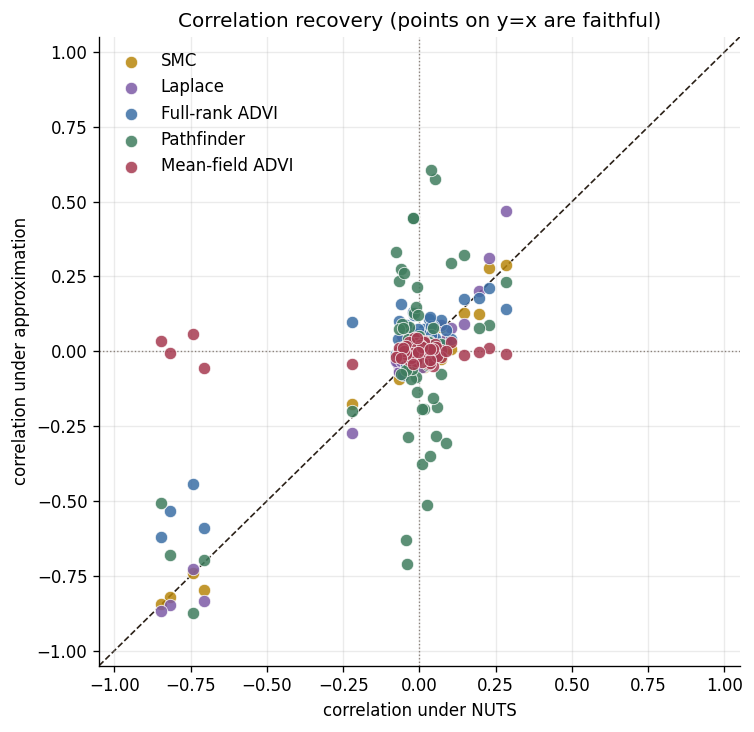

Mean-field ADVI points sit near y=0 regardless of the true (NUTS) correlation.


In [7]:
pairs = [(MEDIA[i], MEDIA[j]) for i in range(len(MEDIA)) for j in range(i + 1, len(MEDIA))]
r_nuts = np.array([np.corrcoef(flat(traces["NUTS"], a), flat(traces["NUTS"], b))[0, 1]
                   for a, b in pairs])

fig, ax = plt.subplots(figsize=(6.4, 6.2))
lim = 1.05
ax.plot([-lim, lim], [-lim, lim], ls="--", color=INK, lw=1, zorder=1)
ax.axhline(0, color=MUTED, lw=0.8, ls=":"); ax.axvline(0, color=MUTED, lw=0.8, ls=":")
for label, _, _ in METHODS:
    if label == "NUTS":
        continue
    r_ap = np.array([pearsonr(flat(traces[label], a), flat(traces[label], b))[0]
                     for a, b in pairs])
    ax.scatter(r_nuts, r_ap, s=55, color=COLOR[label], label=label,
               alpha=0.85, edgecolors="white", linewidths=0.5, zorder=3)
ax.set(xlim=(-lim, lim), ylim=(-lim, lim),
       xlabel="correlation under NUTS", ylabel="correlation under approximation",
       title="Correlation recovery (points on y=x are faithful)")
ax.legend(frameon=False); fig.tight_layout(); plt.show()
print("Mean-field ADVI points sit near y=0 regardless of the true (NUTS) correlation.")

The SMC points should hug the diagonal (exact method, finite-particle scatter);
Laplace, full-rank ADVI and Pathfinder track it more loosely; the mean-field
points lie along the horizontal `y ≈ 0` band — a picture of a method that is
structurally blind to correlation, no matter how strong the true dependence.

---
## 7 — Does it change the decision?

Posterior shape only matters if it moves the number you act on. Below is each
method's **incremental contribution per channel** (the counterfactual "turn this
channel off" effect) with a 90% credible interval, against the **known** truth
(grey line — available because the data is synthetic).

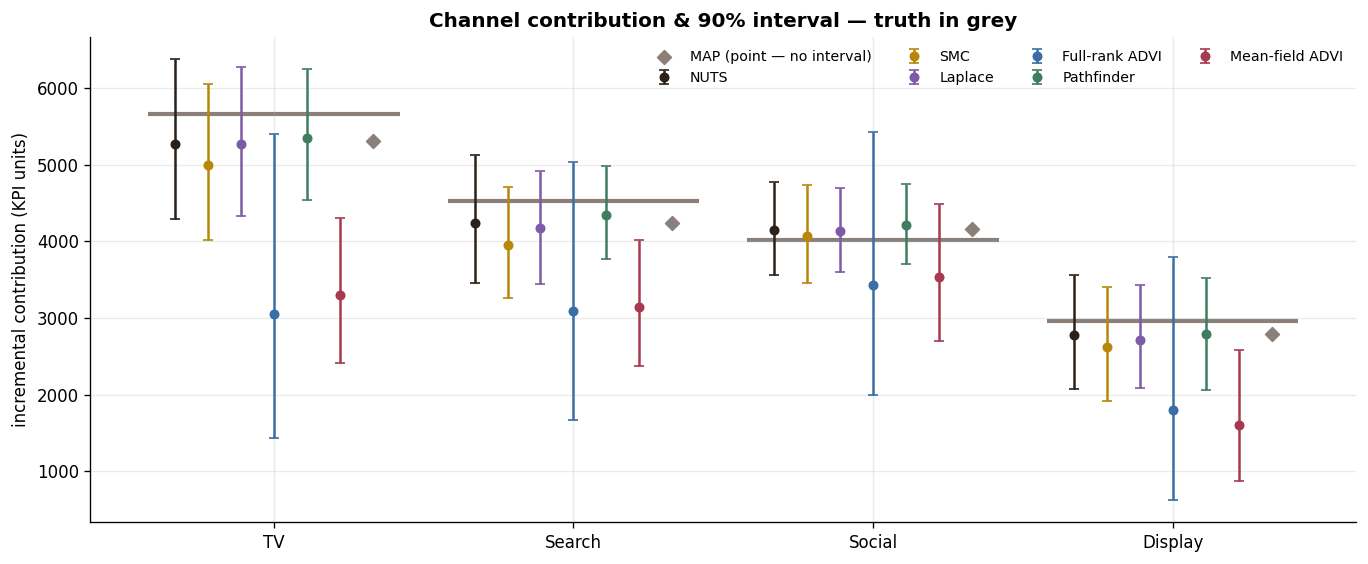

                avg 90% width channels covering truth  fit time (s)
method                                                             
NUTS                     1616                     4/4           9.5
SMC                      1563                     4/4           9.4
Laplace                  1467                     4/4          32.9
Full-rank ADVI           3486                     3/4           5.5
Pathfinder               1359                     4/4           5.5
Mean-field ADVI          1764                     1/4           5.1
MAP                         —         — (no interval)           2.3


In [8]:
fig, ax = plt.subplots(figsize=(11.5, 4.8))
chs = list(sc.channels)
x = np.arange(len(chs))
n_rows = len(METHODS) + 1                       # + the MAP point
off = np.linspace(-0.33, 0.33, n_rows)
for k, (label, _, _) in enumerate(METHODS):
    cc = contribs[label]
    est = np.array([cc.total_contributions[c] for c in chs])
    lo = np.array([cc.contribution_hdi_low[c] for c in chs])
    hi = np.array([cc.contribution_hdi_high[c] for c in chs])
    ax.errorbar(x + off[k], est, yerr=[est - lo, hi - est], fmt="o", ms=5,
                capsize=3, lw=1.5, color=COLOR[label], label=label)
map_est = np.array([float(map_cc.total_contributions[c]) for c in chs])
ax.scatter(x + off[-1], map_est, marker="D", s=34, color=COLOR["MAP"],
           label="MAP (point — no interval)", zorder=3)
for xi, c in zip(x, chs):
    t = float(sc.true_contribution[c])
    ax.hlines(t, xi - 0.42, xi + 0.42, color=MUTED, lw=2.5, zorder=0)
ax.set_xticks(x); ax.set_xticklabels(chs)
ax.set_ylabel("incremental contribution (KPI units)")
ax.set_title("Channel contribution & 90% interval — truth in grey", fontweight="bold")
ax.legend(frameon=False, ncol=4, fontsize=8.5); fig.tight_layout(); plt.show()

# Interval width per method, averaged over channels (narrower ≠ better here).
rows = []
for label, _, _ in METHODS:
    cc = contribs[label]
    w = np.mean([cc.contribution_hdi_high[c] - cc.contribution_hdi_low[c] for c in chs])
    cover = np.mean([cc.contribution_hdi_low[c] <= sc.true_contribution[c] <= cc.contribution_hdi_high[c]
                     for c in chs])
    rows.append({"method": label, "avg 90% width": round(w),
                 "channels covering truth": f"{int(cover*len(chs))}/{len(chs)}",
                 "fit time (s)": round(timings[label], 1)})
rows.append({"method": "MAP", "avg 90% width": "—",
             "channels covering truth": "— (no interval)",
             "fit time (s)": round(timings["MAP"], 1)})
print(pd.DataFrame(rows).set_index("method").to_string())

The **point estimates** cluster together — for a well-identified model even MAP
lands the central answer (the grey diamonds sit near the truth lines). The
**intervals** are where the methods diverge: a mean-field fit's bands are often
the narrowest and may **miss the truth** more often than the nominal 90% would
suggest — over-confidence that would understate the risk of a budget
reallocation. NUTS and SMC — the two exact samplers — should produce
near-identical bands; that agreement is the practical meaning of "exact". And
MAP has no band at all, which is the whole problem with deciding from it: a
reallocation is a bet, and a point estimate prices the bet with no odds.

---
# 8 — How fast, how tunable, how *trustworthy*?

Posterior shape is one axis; a practitioner also needs three practical answers:
**how long does each method take**, **which knob fixes a bad fit**, and **how do
you know from the fit statistics that it worked on *this* model?** Each method
exposes a *different* diagnostic — ELBO for the ADVI family, Pareto k̂ for
Pathfinder, the Hessian for MAP/Laplace, R-hat *across independent runs* plus
the log evidence for SMC, and R-hat / ESS / divergences for NUTS — and this
section reads all of them.

## 8.1 — Relative speed, and the speed–fidelity trade-off

Left: wall-clock per method (from the §2 fits). Right: that time against how
faithfully each method reproduced the §5 ridge — the correlation error
`|corr − NUTS corr|` (0 = matches NUTS). The approximations are cheap, but the
cheapest ones pay in fidelity, and mean-field pays the most on *correlation*.

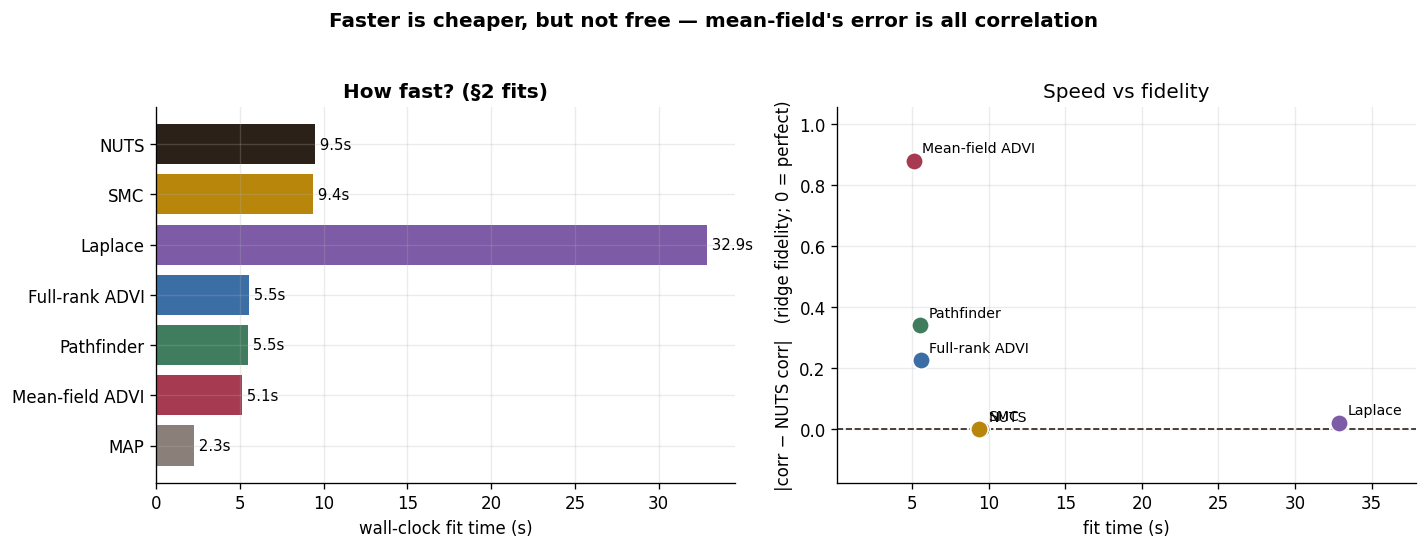

In [9]:
r_by = {label: pearsonr(flat(traces[label], pa), flat(traces[label], pb))[0]
        for label, _, _ in METHODS}
err = {label: abs(r_by[label] - r_by["NUTS"]) for label, _, _ in METHODS}
labels = [m[0] for m in METHODS]
labels_time = labels + ["MAP"]                 # MAP has a time but no draws

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.4))
axL.barh(labels_time, [timings[l] for l in labels_time],
         color=[COLOR[l] for l in labels_time])
axL.invert_yaxis(); axL.set_xlabel("wall-clock fit time (s)")
axL.set_title("How fast? (§2 fits)", fontweight="bold")
for l in labels_time:
    axL.text(timings[l], l, f" {timings[l]:.1f}s", va="center", fontsize=9)
for l in labels:
    axR.scatter(timings[l], err[l], s=110, color=COLOR[l], zorder=3, edgecolors="white")
    axR.annotate(l, (timings[l], err[l]), fontsize=8.5,
                 xytext=(5, 5), textcoords="offset points")
axR.axhline(0, color=INK, lw=1, ls="--")
axR.set(xlabel="fit time (s)",
        ylabel="|corr − NUTS corr|   (ridge fidelity; 0 = perfect)",
        title="Speed vs fidelity")
axR.margins(x=0.18, y=0.2)
fig.suptitle("Faster is cheaper, but not free — mean-field's error is all correlation",
             fontweight="bold", y=1.03)
fig.tight_layout(); plt.show()

## 8.2 — Tuning the ADVI family: iterations & the ELBO trace

ADVI maximises the **ELBO** (equivalently, minimises the loss `−ELBO`) by
stochastic gradient descent. The single knob that decides whether the answer is
right is **`n`, the number of iterations** — stop early and you report an
*unconverged* approximation. The way to *see* convergence is the loss trace: it
must **flatten**. Below we run both variants long enough to converge and read the
tails.

Finished [100%]: Average Loss = 111.36


Finished [100%]: Average Loss = 102.14


Mean-field ADVI   final loss (−ELBO) =   106.3   tail slope/iter = -0.0002   FLAT → converged
Full-rank ADVI    final loss (−ELBO) =   101.2   tail slope/iter = -0.0002   FLAT → converged


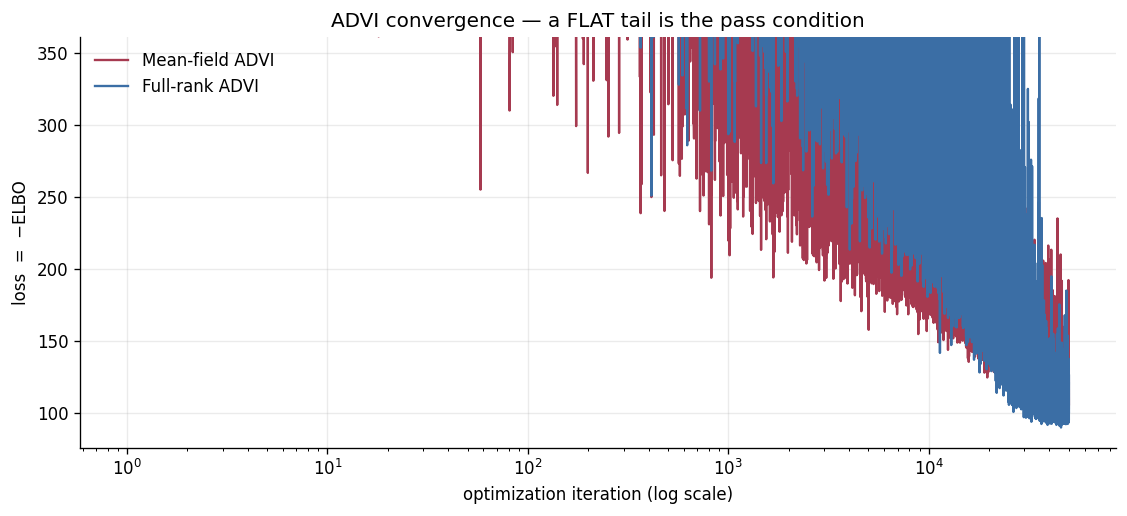

In [10]:
import pymc as pm

elbo = {}
for meth in ("advi", "fullrank_advi"):
    with quiet(), model.model:
        approx = pm.fit(n=50000, method=meth, random_seed=0, progressbar=False)
    elbo[meth] = np.asarray(approx.hist)

fig, ax = plt.subplots(figsize=(9.5, 4.4))
for meth, c, name in [("advi", BERRY, "Mean-field ADVI"),
                      ("fullrank_advi", SKY, "Full-rank ADVI")]:
    h = elbo[meth]
    ax.plot(np.arange(1, len(h) + 1), h, color=c, lw=1.4, label=name)
    tail = h[int(0.9 * len(h)):]
    slope = (tail[0] - tail[-1]) / len(tail)   # >0 means still descending
    print(f"{name:16s}  final loss (−ELBO) = {h[-1]:7.1f}   "
          f"tail slope/iter = {slope:+.4f}   {'FLAT → converged' if abs(slope)<0.01 else 'still descending → raise n'}")
lo = min(elbo['advi'][-1], elbo['fullrank_advi'][-1])
ax.set(xscale="log", ylim=(lo - 25, lo + 260),
       xlabel="optimization iteration (log scale)", ylabel="loss  =  −ELBO",
       title="ADVI convergence — a FLAT tail is the pass condition")
ax.legend(frameon=False); fig.tight_layout(); plt.show()

**How to read it.** (1) **Flat tail = converged.** A tail still sloping down means
you stopped early — the posterior you sampled is not the ELBO optimum; raise `n`
(or the Adam learning rate). (2) **Full-rank should end up *below* mean-field.**
Its covariance family is strictly richer, so at convergence its `−ELBO` is lower.
If you see full-rank sitting *above* mean-field (as it does at small `n`, because
it has `~d²/2` extra covariance parameters to fit), that is the tell that full-rank
has **not** converged yet — not that mean-field is better. The ELBO value itself is
**not** a goodness-of-fit score you can compare across *models*, but the trace's
shape is exactly how you certify *this* fit converged.

## 8.3 — Tuning Pathfinder: covariance rank (`maxcor`) & the Pareto k̂ verdict

Pathfinder approximates the posterior with a **low-rank-plus-diagonal** Gaussian
built from the L-BFGS optimizer trajectory, then importance-resamples. Its most
consequential knob is **`maxcor`** — the L-BFGS history length, which *is* the rank
of that covariance, i.e. how many correlated directions it can represent. That is
why §5's default under-recovered the ridge. But tuning is only half the job: PSIS
importance sampling returns a **Pareto k̂** that grades whether the Gaussian
proposal is even a usable match to the true posterior.

Output()

Output()

Output()

Output()

Output()

...

Output()

Output()

Output()

Output()

Output()

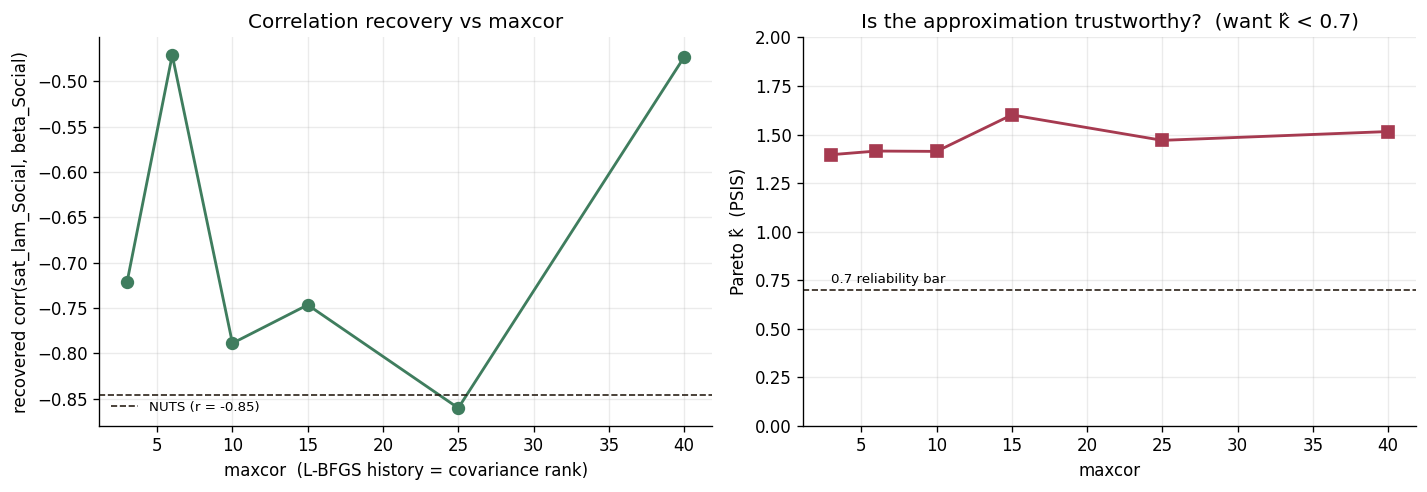

Pareto k̂ by maxcor: {3: 1.4, 6: 1.41, 10: 1.41, 15: 1.6, 25: 1.47, 40: 1.52}


In [11]:
import pymc_extras as pmx
from pymc_extras.inference.pathfinder.pathfinder import LBFGSConfig

maxcors = [3, 6, 10, 15, 25, 40]
pf_r, pf_k = [], []
for mc in maxcors:
    with quiet(), model.model:
        dt = pmx.fit(method="pathfinder", num_draws=1500, num_paths=8, random_seed=0,
                     lbfgs_config=LBFGSConfig(maxcor=mc))
    pf_r.append(pearsonr(flat(dt.posterior, pa), flat(dt.posterior, pb))[0])
    pf_k.append(float(np.asarray(dt.pathfinder["pareto_k"])))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.2))
a1.plot(maxcors, pf_r, "o-", color=LEAF, lw=1.7, ms=7)
a1.axhline(r_by["NUTS"], color=INK, ls="--", lw=1, label=f"NUTS (r = {r_by['NUTS']:+.2f})")
a1.set(xlabel="maxcor  (L-BFGS history = covariance rank)",
       ylabel=f"recovered corr({pa}, {pb})", title="Correlation recovery vs maxcor")
a1.legend(frameon=False, fontsize=8)
a2.plot(maxcors, pf_k, "s-", color=BERRY, lw=1.7, ms=7)
a2.axhline(0.7, color=INK, ls="--", lw=1)
a2.text(maxcors[0], 0.72, "0.7 reliability bar", fontsize=8, va="bottom")
a2.set(xlabel="maxcor", ylabel="Pareto k̂  (PSIS)",
       title="Is the approximation trustworthy?  (want k̂ < 0.7)")
a2.set_ylim(0, max(2.0, max(pf_k) * 1.1))
fig.tight_layout(); plt.show()
print("Pareto k̂ by maxcor:", {m: round(k, 2) for m, k in zip(maxcors, pf_k)})

**How to read it.** A too-small `maxcor` *structurally* caps the correlation
Pathfinder can express — raising it lets the recovered correlation climb toward the
NUTS line (left panel), though the path is erratic because it is an optimisation on
a curved ridge. The right panel is the more important one: on this model **Pareto
k̂ never drops below 0.7 for any `maxcor`** (it sits near ~1.5). That is Pathfinder
telling you its single-Gaussian-per-path proposal is a poor match to the true
posterior, so the importance weights are unreliable — *even the settings that
happen to land the correlation are not to be trusted.* The right response to a high
k̂ is not "tune harder"; it is **use NUTS** (raising `num_paths` / `num_draws_per_path`
helps only when k̂ is borderline).

## 8.4 — MAP & Laplace: the point, and the curvature around it

**MAP** answers the cheapest question there is: *does gradient ascent find a
well-behaved mode at all?* An optimizer that stalls or returns NaN is almost
always a mechanical defect — data on wild scales, an undefined gradient, a
constraint boundary — caught in seconds instead of after an hour of NUTS warmup.

**Laplace** goes one step further: expand the log posterior to second order at
the MAP point $\hat\theta$ and report the Gaussian
$\mathcal{N}(\hat\theta,\, H^{-1})$, where $H$ is the negative Hessian. Two
consequences follow. First, the *attempt itself* is a diagnostic: if $H$ is not
positive definite, some direction of parameter space is **flat at the mode** — a
weak-identification flag that *names the parameters involved* before any MCMC
has run. Second, the approximation is exactly symmetric in the unconstrained
space, so whatever genuine skew the posterior has is structurally invisible —
which we can measure, because we have NUTS to compare against.

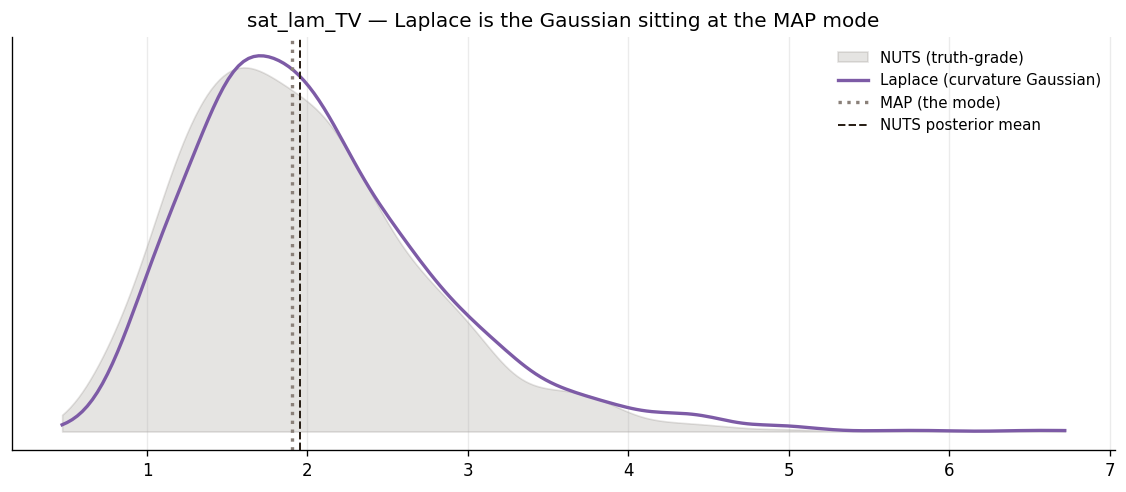

skew of sat_lam_TV:  NUTS = +0.78   Laplace = +1.15   (Laplace is symmetric in the unconstrained space by construction)
mode vs mean gap: MAP = 1.904   NUTS mean = 1.956   (0.07 posterior SDs apart)
median SD ratio vs NUTS — Laplace: 0.94  (1.0 = calibrated; see §4)


In [12]:
from scipy.stats import skew

p_skew = f"sat_lam_{focus}" if f"sat_lam_{focus}" in SCALARS else SCALARS[0]
nuts_d, lap_d = flat(traces["NUTS"], p_skew), flat(traces["Laplace"], p_skew)

fig, ax = plt.subplots(figsize=(9.5, 4.2))
g = np.linspace(min(nuts_d.min(), lap_d.min()), max(nuts_d.max(), lap_d.max()), 250)
ax.fill_between(g, gaussian_kde(nuts_d)(g), color=INK, alpha=0.12, label="NUTS (truth-grade)")
kde_line(ax, lap_d, PLUM, "Laplace (curvature Gaussian)")
ax.axvline(MAP_POINT[p_skew], color=MUTED, ls=":", lw=2, label="MAP (the mode)")
ax.axvline(nuts_d.mean(), color=INK, ls="--", lw=1.2, label="NUTS posterior mean")
ax.set(title=f"{p_skew} — Laplace is the Gaussian sitting at the MAP mode",
       yticks=[])
ax.legend(frameon=False, fontsize=9); fig.tight_layout(); plt.show()

print(f"skew of {p_skew}:  NUTS = {skew(nuts_d):+.2f}   Laplace = {skew(lap_d):+.2f}"
      "   (Laplace is symmetric in the unconstrained space by construction)")
print(f"mode vs mean gap: MAP = {MAP_POINT[p_skew]:.3f}   "
      f"NUTS mean = {nuts_d.mean():.3f}   "
      f"({abs(MAP_POINT[p_skew] - nuts_d.mean()) / nuts_d.std():.2f} posterior SDs apart)")
print(f"median SD ratio vs NUTS — Laplace: {ratio['Laplace'].median():.2f}  "
      "(1.0 = calibrated; see §4)")

**How to read it.** The Laplace curve is centred on the dotted MAP mode; for a
skewed posterior the mode sits systematically to one side of the mean, so both
the point *and* the Gaussian around it inherit that offset. The printed skew
comparison quantifies what the picture shows: whatever asymmetry survives the
constraint transform is real posterior shape that a quadratic expansion cannot
carry. In the escalation ladder these two are the **reconnaissance rung** — MAP
to prove a mode exists, Laplace to get a first read on curvature and catch
weakly-identified directions — never the answer you report.

> **The optimizer *is* the fit.** A Laplace approximation is a quadratic
> expansion *at the point the optimizer stopped*. With the default quasi-Newton
> (BFGS) optimizer on this model we observed a run that stopped early on a
> ridge and reported a **median SD 76× wider than NUTS** — not a property of
> the Laplace idea, just curvature measured somewhere that is not the mode.
> This notebook passes `optimize_method="trust-ncg", use_hess=True` (an
> exact-Hessian trust-region), which reliably reaches the mode: median SD
> ratio ≈ 0.94 vs NUTS here. If a Laplace fit's spreads look absurd, suspect
> the optimizer before the method.

## 8.5 — SMC: the exact second opinion (R-hat across runs & the evidence)

SMC's diagnostics answer two questions no other method here can. **(1) Is the
posterior multimodal?** Each SMC `chain` is a fully *independent* tempered
particle population, initialized at the prior — so every mode's basin is
populated before the modes exist, and no run can get mode-locked the way a
gradient chain can. R-hat computed **across** the runs is therefore a genuine
multimodality verdict: on this clean, well-identified world it should be ≈ 1.
**(2) Which model does the data prefer?** The tempering ladder's importance
weights telescope into the **log marginal likelihood** — the model evidence —
whose between-model differences are log Bayes factors. Per-run agreement on the
evidence is itself a health check.

approximate           : False   (SMC is EXACT — no 'uncalibrated' banner)
R-hat across runs     : 1.014   (> 1.01 would mean the independent runs
                        disagree -> a multimodal or badly-degenerate posterior)
bulk ESS              : 315
log evidence (mean)   : -108.1
log evidence per run  : [-106.8, -108.6, -108.0, -109.0]


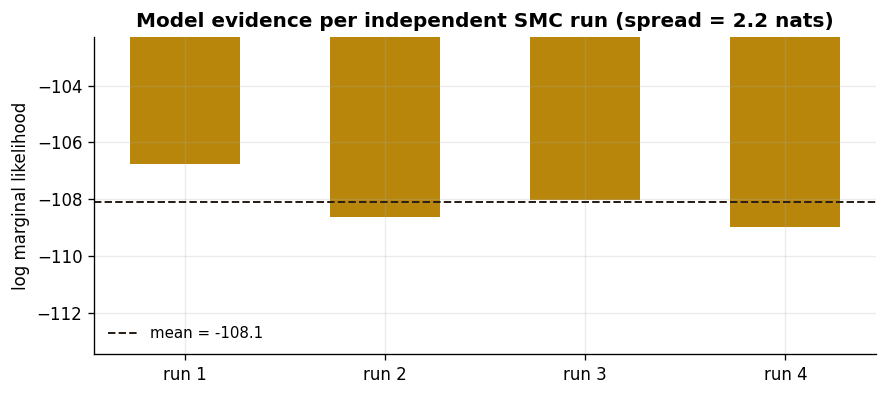

In [13]:
d = smc_res.diagnostics
print(f"approximate           : {smc_res.approximate}   (SMC is EXACT — no 'uncalibrated' banner)")
print(f"R-hat across runs     : {d['rhat_max']:.3f}   (> 1.01 would mean the independent runs")
print( "                        disagree -> a multimodal or badly-degenerate posterior)")
print(f"bulk ESS              : {d['ess_bulk_min']:.0f}")
lml_runs = d.get("log_marginal_likelihood_per_run") or []
if lml_runs:
    print(f"log evidence (mean)   : {d['log_marginal_likelihood']:.1f}")
    print(f"log evidence per run  : {[round(v, 1) for v in lml_runs]}")

    fig, ax = plt.subplots(figsize=(7.5, 3.4))
    names = [f"run {i + 1}" for i in range(len(lml_runs))]
    ax.bar(names, lml_runs, color=GOLD, width=0.55)
    ax.axhline(d["log_marginal_likelihood"], color=INK, ls="--", lw=1.2,
               label=f"mean = {d['log_marginal_likelihood']:.1f}")
    spread = max(lml_runs) - min(lml_runs)
    pad = max(3.0, spread * 2)
    ax.set_ylim(min(lml_runs) - pad, max(lml_runs) + pad)
    ax.set_ylabel("log marginal likelihood")
    ax.set_title(f"Model evidence per independent SMC run (spread = {spread:.1f} nats)",
                 fontweight="bold")
    ax.legend(frameon=False, fontsize=9); fig.tight_layout(); plt.show()

**How to read it.** A tight per-run evidence spread (a nat or two) plus R-hat ≈ 1
says the four populations independently found the same posterior and the same
evidence — the fit is trustworthy. The particle count is the knob that buys this:
when we first ran this notebook with **500** particles per run, the four runs
*disagreed* — R-hat across runs 1.43, bulk ESS 8, a **14-nat** evidence spread —
not because the posterior is multimodal but because each small population was a
noisy estimate of it. Quadrupling the particles brought the runs into agreement;
that convergence-with-more-particles is exactly how you distinguish "SMC needs a
bigger population" from "the posterior really has structure" (real modes do not
merge as particles grow). Where you would actually reach for SMC in
practice: **(a)** NUTS chains disagree with clean per-chain traces and you need
to know whether the posterior *really* has modes (label switching, a reflected
latent factor, an adstock↔carryover ridge) or NUTS was merely stuck; and
**(b)** two candidate model structures need adjudicating — fit both with SMC and
difference the log evidences for a log Bayes factor, something no other method
in this notebook can provide. What SMC is **not** is a speedup: per effective
draw it costs more than NUTS here, and its independent-Metropolis particle moves
degrade in high dimension. Exact, patient, occasionally indispensable.

## 8.6 — Reading NUTS: R-hat, ESS & divergences

NUTS is the reference, but it is not exempt from diagnostics — it just has *good*
ones. **R-hat** compares within- vs between-chain variance (want ≤ 1.01);
**ESS** (effective sample size, bulk & tail) says how many *independent* draws the
autocorrelated chain is worth (want hundreds+); **divergences** flag places the
sampler could not integrate the geometry (want 0). Here is the same model, graded.

NUTS per-parameter diagnostics (r_hat ≤ 1.01 good; ESS in the hundreds+):
                       r_hat  ess_bulk  ess_tail
intercept              1.003    1661.0    1522.0
trend_slope            1.001    2237.0    1757.0
adstock_alpha_TV       1.000    1985.0    1412.0
sat_lam_TV             1.001    1429.0    1184.0
beta_TV                1.002    1403.0    1211.0
adstock_alpha_Search   1.002    1591.0    1093.0
sat_lam_Search         1.001    1316.0    1032.0
beta_Search            1.004    1246.0    1011.0
adstock_alpha_Social   1.007    3041.0    1488.0
sat_lam_Social         1.000    1390.0    1353.0
beta_Social            1.001    1396.0    1431.0
adstock_alpha_Display  1.002    2213.0    1337.0
sat_lam_Display        1.002    1419.0    1334.0
beta_Display           1.004    1324.0    1418.0
sigma                  1.003    1892.0    1451.0

divergences = 0    max R-hat = 1.007    → clean fit


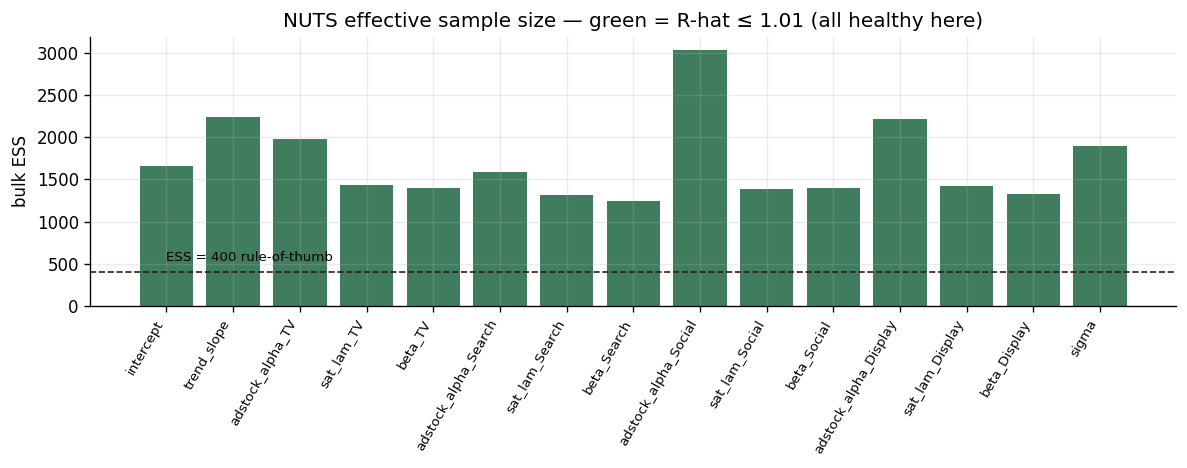

In [14]:
from mmm_framework.utils import arviz_compat

summ = arviz_compat.summary(nuts_res.trace, var_names=SCALARS)
cols = [c for c in ("r_hat", "ess_bulk", "ess_tail") if c in summ.columns]
print("NUTS per-parameter diagnostics (r_hat ≤ 1.01 good; ESS in the hundreds+):")
print(summ.loc[SCALARS, cols].round({"r_hat": 3, "ess_bulk": 0, "ess_tail": 0}).to_string())
print(f"\ndivergences = {nuts_res.diagnostics['divergences']}    "
      f"max R-hat = {nuts_res.diagnostics['rhat_max']:.3f}    "
      f"→ {'clean fit' if nuts_res.diagnostics['divergences']==0 and nuts_res.diagnostics['rhat_max']<=1.01 else 'inspect!'}")

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(SCALARS))
ess = summ.loc[SCALARS, "ess_bulk"].values
bad = summ.loc[SCALARS, "r_hat"].values > 1.01
ax.bar(x, ess, color=[BERRY if b else LEAF for b in bad])
ax.axhline(400, color=INK, ls="--", lw=1)
ax.text(0, ess.max() * 0.04 + 410, "ESS = 400 rule-of-thumb", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(SCALARS, rotation=60, ha="right", fontsize=8)
ax.set(ylabel="bulk ESS",
       title="NUTS effective sample size — green = R-hat ≤ 1.01 (all healthy here)")
fig.tight_layout(); plt.show()

## 8.7 — Diagnostic cheat-sheet

| Method | Fit statistic | Healthy | Trouble → what to do |
|---|---|---|---|
| MAP | optimizer result | converges to finite point | stall / NaN → rescale data, check gradients/priors |
| Laplace | Hessian at the mode | positive definite | not PSD → weakly-identified direction; fix identification |
| ADVI / full-rank | `−ELBO` trace (`approx.hist`) | tail **flat** | still descending → raise `n` / learning rate |
| ADVI / full-rank | full-rank vs mean-field `−ELBO` | full-rank **≤** mean-field | full-rank higher → not converged (more `n`) |
| Pathfinder | **Pareto k̂** (`idata.pathfinder.pareto_k`) | **k̂ < 0.7** | k̂ ≥ 0.7 → proposal poor; try `num_paths`↑, else **use NUTS** |
| Pathfinder | `maxcor` (L-BFGS history) | ≳ #correlated dims | too small → cannot represent ridges |
| SMC | **R-hat across independent runs** | **≤ 1.01** | > 1.01 → real multimodality; fix identification, not the sampler |
| SMC | per-run **log evidence** spread | a nat or two | wide spread → more `draws` (particles) / more runs |
| NUTS | **R-hat** | **≤ 1.01** | > 1.01 → chains disagree; more `tune`, reparameterize — or confirm modes with SMC |
| NUTS | bulk / tail **ESS** | hundreds+ | low → more `draws`; raise `target_accept` |
| NUTS | **divergences** | **0** | > 0 → `target_accept` 0.9 → 0.99, reparameterize |

The through-line: **every method can produce a plausible-looking posterior that is
wrong**, and each one hands you the statistic that catches it. Read the statistic
*before* you read the answer. The full failed-fit escalation ladder — which
diagnostic points to which fix, in cost order — is
`technical-docs/sampling-failure-playbook.md`.

---
## 9 — Takeaways: when to use which

**The two exact samplers:**

- **NUTS** (`nuts`) is the workhorse whose uncertainty you should report. It
  captures correlation, skew, and curvature, at the best cost per effective
  draw. Use it for every number that leaves the room.
- **SMC** (`smc`) is the *other* exact method — the second opinion, not a
  speedup. Reach for it when NUTS chains disagree with clean per-chain traces
  (its R-hat across independent tempered runs distinguishes "NUTS was stuck"
  from "the posterior really has modes"), and when you need the **log marginal
  likelihood** to compare model structures by Bayes factor — the one quantity
  no other method here provides. It is slower than NUTS on well-behaved
  posteriors and degrades in very high dimension.

**The point and the approximations (model checking only):**

- **MAP** (`map`) is the fastest possible probe: *does a well-behaved mode
  exist?* Seconds, one point, no uncertainty — a stalling or NaN optimizer is a
  mechanical defect caught before any sampling. Never a basis for intervals.
- **Laplace** (`laplace`) is MAP plus the Gaussian curvature at the mode — a
  more stable quick read than bare MAP, with a built-in identification probe (a
  non-positive-definite Hessian names the flat directions). Symmetric by
  construction, so real skew is lost — and only as good as the optimum it is
  expanded at: on ridgey posteriors prefer
  `optimize_method="trust-ncg", use_hess=True` over the fragile quasi-Newton
  default (§8.4).
- **Mean-field ADVI** (`advi`) is the fastest *distributional* check but
  **cannot see correlations** and is typically **over-confident**. Great for
  "does the model build and give sane point estimates?"; never for intervals or
  reallocations.
- **Full-rank ADVI** (`fullrank_advi`) recovers much of the linear correlation
  structure — the ridge — so its *joint* shape is far better than mean-field. But
  its marginal spread is still uncalibrated (here it *over*-dispersed, reporting
  bands wider than NUTS), and ELBO optimisation can be unstable. Reach for it to
  *see* the correlation structure, not to size intervals.
- **Pathfinder** (`pathfinder`) is a fast, correlation-aware initialiser whose
  quality *varies by model* — and it tells you when it is failing. Its correlation
  recovery is capped by `maxcor` and, on this ridge, its **Pareto k̂ ≈ 1.5 (≫ 0.7)**
  flagged the approximation as untrustworthy no matter how we tuned it (§8.3). Trust
  it when k̂ < 0.7; otherwise fall back to NUTS.

**Always read the fit statistic before the answer** (§8.7): a flat ELBO tail for
ADVI, k̂ < 0.7 for Pathfinder, a positive-definite Hessian for Laplace, tight
per-run evidence + R-hat ≈ 1 across runs for SMC, R-hat ≤ 1.01 / healthy ESS /
zero divergences for NUTS. Each method can produce a plausible-looking-but-wrong
posterior; each also hands you the number that catches it.

**The rule the framework enforces** (`MMMResults.approximate == True`, banners in
every report — NUTS **and SMC** are exempt because both are exact): approximate
fits are for **iterating on the model**, not for **deciding with it**. Re-fit
with NUTS before you trust an interval — this notebook is why. And when a fit
*fails*, work the escalation ladder in
`technical-docs/sampling-failure-playbook.md` (companion research post: *When
Sampling Fails* on the docs site): diagnose → cheap reconnaissance (MAP /
Laplace / VI) → fix identification → sampler settings → SMC as the multimodality
second opinion.

> Reproduce or extend: swap `dgp.make_clean` for a harder world
> (`make_multicollinearity`, `make_saturation_misspec`) to watch the approximation
> gap widen, or raise `N_APPROX` / ADVI iterations to see how much of the gap is
> optimization vs. the family being wrong. Authoring script:
> `nbs/builders/build_approximate_posteriors.py`.